# Quality Control for the processed parquet

In [3]:
import pandas as pd
from pathlib import Path

root = next(p for p in Path.cwd().parents if (p / "config.yml").exists())

panel = pd.read_parquet(root / "data/processed_data/analysis_panel.parquet")
print(panel.shape)
print(panel.dtypes)
panel.head(20)

(14504, 34)
YEAR                              int16
GEOGRAPHY_CODE                 category
GEOGRAPHY_NAME                 category
IS8_SECTOR                     category
EMPLOYEES                       float32
BUSINESSES                      float32
unemployment_rate               float64
transport_to_employer           float64
drive_to_employer               float64
cycle_to_employer               float64
broadband                       float64
coverage_4g                     float64
gcse_age19                      float64
apprenticeship_starts           float64
apprenticeship_achievements     float64
nvq_level3                      float64
fe_participation                float64
housing_net_additions           float64
enterprise_birth_rate           float64
enterprise_death_rate           float64
enterprise_high_growth_rate     float64
REGION                              str
COUNTY_UA                           str
lq_bus                          Float64
emp_share                   

,YEAR,GEOGRAPHY_CODE,GEOGRAPHY_NAME,IS8_SECTOR,EMPLOYEES,BUSINESSES,unemployment_rate,transport_to_employer,drive_to_employer,cycle_to_employer,...,emp_share,lq_emp,gd_emp,gd_bus,n_years_emp,n_years_bus,related_variety,within_sector_diversity,size_large_share,size_micro_share
0,2016,E06000001,Hartlepool,Advanced Manufacturing,1470.0,25.0,4.6,12.900208,7.790802,10.070582,...,0.048197,1.648198,-0.011762,-0.099994,7,7,1.032564,1.332179,0.0,1.0
1,2016,E06000001,Hartlepool,Creative Industries,450.0,110.0,4.6,12.900208,7.790802,10.070582,...,0.014754,0.281144,0.051147,-0.016593,7,7,1.032564,2.200516,0.0,1.0
2,2016,E06000001,Hartlepool,Defence,0.0,0.0,4.6,12.900208,7.790802,10.070582,...,0.0,0.0,NaN,NaN,0,0,1.032564,0.000000,<NA>,<NA>
3,2016,E06000001,Hartlepool,Digital and Technologies,1510.0,440.0,4.6,12.900208,7.790802,10.070582,...,0.049508,0.68244,-0.035441,-0.062803,7,7,1.032564,1.072313,0.0,1.0
4,2016,E06000001,Hartlepool,Financial Services,285.0,40.0,4.6,12.900208,7.790802,10.070582,...,0.009344,0.154102,-0.054407,0.049395,7,7,1.032564,1.213008,0.0,0.75
5,2016,E06000001,Hartlepool,Life Sciences,40.0,0.0,4.6,12.900208,7.790802,10.070582,...,0.001311,0.473936,-0.057544,NaN,7,0,1.032564,0.000000,<NA>,<NA>
6,2016,E06000001,Hartlepool,Professional and Business Services,2630.0,870.0,4.6,12.900208,7.790802,10.070582,...,0.08623,0.461236,0.025961,-0.046130,7,7,1.032564,1.830641,0.0,0.965517
7,2016,E06000002,Middlesbrough,Advanced Manufacturing,620.0,25.0,5.1,15.372879,8.457817,11.335077,...,0.010622,0.36324,0.006576,0.029010,7,7,1.075517,1.332179,0.0,0.8
8,2016,E06000002,Middlesbrough,Creative Industries,1320.0,180.0,5.1,15.372879,8.457817,11.335077,...,0.022614,0.430924,0.028398,0.012496,7,7,1.075517,2.328951,0.0,1.0
9,2016,E06000002,Middlesbrough,Defence,0.0,0.0,5.1,15.372879,8.457817,11.335077,...,0.0,0.0,NaN,NaN,0,0,1.075517,0.000000,<NA>,<NA>


In [4]:
"""
Quality control script for analysis_panel.parquet
Tests each processing stage from processor.py and indicators.py
"""

import pandas as pd
import numpy as np
from pathlib import Path

PANEL_PATH = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet"

df = pd.read_parquet(PANEL_PATH)

EXPECTED_SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Defence",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

INDICATOR_COLS = [
    "lq_emp", "lq_bus",
    "emp_share",
    "growth_emp", "cagr_emp",
    "growth_bus", "cagr_bus",
    "related_variety",
    "size_large_share", "size_micro_share",
]

YEARS_EMP  = list(range(2016, 2023))
YEARS_BUS  = list(range(2016, 2023))

sep = lambda title: print(f"\n{'='*60}\n{title}\n{'='*60}")

# =============================================================================
# 1. BASIC SHAPE
# =============================================================================
sep("1. BASIC SHAPE")
print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumns:\n{list(df.columns)}")

# =============================================================================
# 2. NO TOTAL ROWS (should have been removed by build_indicators)
# =============================================================================
sep("2. NO 'Total' SECTOR ROWS")
total_rows = df[df["IS8_SECTOR"] == "Total"]
print(f"'Total' rows remaining: {len(total_rows)}  (expected 0)")

# =============================================================================
# 3. SECTOR COVERAGE
# =============================================================================
sep("3. SECTOR COVERAGE")
found = sorted(df["IS8_SECTOR"].unique())
print(f"Sectors found ({len(found)}):\n  {found}")
missing = [s for s in EXPECTED_SECTORS if s not in found]
extra   = [s for s in found if s not in EXPECTED_SECTORS]
if missing: print(f"\n⚠️  Missing sectors: {missing}")
if extra:   print(f"⚠️  Unexpected sectors: {extra}")
if not missing and not extra: print(f"✓ All {len(EXPECTED_SECTORS)} IS8 sectors present, no extras")

# =============================================================================
# 4. LAD COUNT
# =============================================================================
sep("4. LAD COUNT")
n_lads = df["GEOGRAPHY_CODE"].nunique()
print(f"Unique LADs: {n_lads}  (expect 350: 296 England + 32 Scotland + 22 Wales)")

# =============================================================================
# 5. YEAR COVERAGE
# =============================================================================
sep("5. YEAR COVERAGE")
years = sorted(df["YEAR"].unique())
print(f"Years present: {years}")

# =============================================================================
# 6. PANEL BALANCE — every LAD x sector x year should exist
# =============================================================================
sep("6. PANEL BALANCE")
lads    = df["GEOGRAPHY_CODE"].unique()
sectors = df[df["IS8_SECTOR"] != "Total"]["IS8_SECTOR"].unique()
expected_rows = len(lads) * len(sectors) * len(years)
print(f"Actual rows:   {len(df):,}")
print(f"Expected rows: {expected_rows:,}  ({len(lads)} LADs × {len(sectors)} sectors × {len(years)} years)")
if len(df) != expected_rows:
    # identify gaps
    full_idx = pd.MultiIndex.from_product(
        [lads, sectors, years],
        names=["GEOGRAPHY_CODE", "IS8_SECTOR", "YEAR"]
    )
    actual_idx = pd.MultiIndex.from_frame(df[["GEOGRAPHY_CODE", "IS8_SECTOR", "YEAR"]])
    missing_combos = full_idx.difference(actual_idx)
    print(f"⚠️  Missing combinations: {len(missing_combos):,}")
    print(missing_combos.to_frame(index=False).head(20))
else:
    print("✓ Panel is balanced")

# =============================================================================
# 7. INDICATOR COLUMNS — presence and null rates
# =============================================================================
sep("7. INDICATOR NULL RATES")
for col in INDICATOR_COLS:
    if col not in df.columns:
        print(f"⚠️  MISSING column: {col}")
    else:
        null_pct = df[col].isna().mean() * 100
        flag = "⚠️ " if null_pct > 5 else "✓ "
        print(f"{flag}{col:25s}  {null_pct:5.1f}% null")

# =============================================================================
# 8. LOCATION QUOTIENT SANITY
# =============================================================================
sep("8. LOCATION QUOTIENT SANITY")
for col in ["lq_emp", "lq_bus"]:
    if col not in df.columns:
        continue
    neg = (df[col] < 0).sum()
    extreme = (df[col] > 20).sum()
    median  = df[col].median()
    print(f"{col}: median={median:.3f}  negative={neg}  >20={extreme}")
    if neg > 0:
        print(f"  ⚠️  {neg} negative LQ values — check zero-division or bad merge")

# =============================================================================
# 9. GROWTH RATE SANITY
# =============================================================================
sep("9. GROWTH RATE SANITY")
for col in ["growth_emp", "growth_bus", "cagr_emp", "cagr_bus"]:
    if col not in df.columns:
        continue
    q = df[col].quantile([0.01, 0.25, 0.5, 0.75, 0.99]).round(3).to_dict()
    print(f"{col}: p1={q[0.01]}  p25={q[0.25]}  p50={q[0.5]}  p75={q[0.75]}  p99={q[0.99]}")

# Check growth rates are only on latest year rows (they're constant per LAD x sector)
if "cagr_emp" in df.columns:
    cagr_non_null_years = df[df["cagr_emp"].notna()]["YEAR"].value_counts()
    print(f"\ncagr_emp non-null row count by year (should be same every year — it's time-invariant):")
    print(cagr_non_null_years.sort_index())

# =============================================================================
# 10. RELATED VARIETY — entropy should be >= 0
# =============================================================================
sep("10. RELATED VARIETY SANITY")
if "related_variety" in df.columns:
    neg = (df["related_variety"] < 0).sum()
    print(f"Negative entropy values: {neg}  (expected 0)")
    print(df["related_variety"].describe().round(4))

# =============================================================================
# 11. SIZE SHARES — must sum to <= 1, no negatives
# =============================================================================
sep("11. SIZE SHARE SANITY")
for col in ["size_large_share", "size_micro_share"]:
    if col not in df.columns:
        continue
    neg   = (df[col] < 0).sum()
    above = (df[col] > 1).sum()
    print(f"{col}: negative={neg}  >1={above}  median={df[col].median():.3f}")

if "size_large_share" in df.columns and "size_micro_share" in df.columns:
    combined = df["size_large_share"].fillna(0) + df["size_micro_share"].fillna(0)
    over = (combined > 1.01).sum()
    print(f"large_share + micro_share > 1: {over} rows  (expected 0)")

# =============================================================================
# 12. ONS INDICATORS — check key columns landed
# =============================================================================
sep("12. ONS INDICATOR COLUMNS")
ons_cols = [c for c in df.columns if c not in (
    ["YEAR", "GEOGRAPHY_CODE", "GEOGRAPHY_NAME", "IS8_SECTOR",
     "EMPLOYEES", "BUSINESSES"] + INDICATOR_COLS
)]
print(f"ONS columns found ({len(ons_cols)}):\n  {ons_cols}")

# Null rate per ONS col — should be consistent across years (time-invariant)
if ons_cols:
    print("\nNull rate per ONS column:")
    for col in ons_cols:
        null_pct = df[col].isna().mean() * 100
        flag = "⚠️ " if null_pct > 30 else "  "
        print(f"{flag}  {col:40s}  {null_pct:5.1f}% null")

# =============================================================================
# 13. DUPLICATE ROWS
# =============================================================================
sep("13. DUPLICATE ROWS")
key_cols = ["YEAR", "GEOGRAPHY_CODE", "IS8_SECTOR"]
dups = df.duplicated(subset=key_cols).sum()
print(f"Duplicate (YEAR, GEOGRAPHY_CODE, IS8_SECTOR) rows: {dups}  (expected 0)")
if dups > 0:
    print(df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(10))

# =============================================================================
# 14. GEOGRAPHY CODE FORMAT
# =============================================================================
sep("14. GEOGRAPHY CODE FORMAT")
bad_codes = df[~df["GEOGRAPHY_CODE"].astype(str).str.match(r"^[EWS]\d{8}$")]["GEOGRAPHY_CODE"].unique()
print(f"Malformed geography codes: {len(bad_codes)}  (expected 0)")
if len(bad_codes): print(bad_codes[:20])

# =============================================================================
# 15. SPECIFIC KNOWN RISK: working_age_pop column name
# =============================================================================
sep("15. KNOWN RISK — working_age_pop column")
wap_candidates = [c for c in df.columns if "working" in c.lower() or "age" in c.lower()]
print(f"Columns matching 'working' or 'age': {wap_candidates}")
if not wap_candidates:
    print("⚠️  No working-age population column found — business_density will be all NaN")

# =============================================================================
# SUMMARY
# =============================================================================
sep("SUMMARY")
print(f"Panel shape: {df.shape}")
print(f"LADs: {df['GEOGRAPHY_CODE'].nunique()}")
print(f"Sectors: {df['IS8_SECTOR'].nunique()}")
print(f"Years: {sorted(df['YEAR'].unique())}")
print(f"Indicators: {[c for c in INDICATOR_COLS if c in df.columns]}")
print(f"ONS cols: {len(ons_cols)}")


1. BASIC SHAPE
Rows:    14,504
Columns: 34

Columns:
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'REGION', 'COUNTY_UA', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']

2. NO 'Total' SECTOR ROWS
'Total' rows remaining: 0  (expected 0)

3. SECTOR COVERAGE
Sectors found (7):
  ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']
✓ All 7 IS8 sectors present, no extras

4. LAD COUNT
Unique LADs: 29

In [5]:
emp = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/employee_counts/Employee_counts_IS8_LADs.parquet")
print(sorted(emp["IS8_SECTOR"].unique()))

['Advanced manufacturing', 'Creative Industries', 'Defence sector', 'Digital and Technology', 'Financial Services', 'Life Sciences', 'Professional and Business Services', 'Total']


In [6]:
crosswalk = pd.read_csv("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V2).csv")
print(crosswalk["CHGIND"].value_counts(dropna=False))
print(crosswalk.columns.tolist())

CHGIND
NaN    7286
Name: count, dtype: int64
['MSOA11CD', 'MSOA11NM', 'CHGIND', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LAD22NMW', 'ObjectId']


In [7]:
import os
boundaries = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/"
print(os.listdir(boundaries))

['MSOA_to_English_combined_authorities.csv', 'Middle_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V3_-4477917303172606123.geojson', 'IZ2022_to_council_area.csv', 'MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V2).csv', 'SG_IZ_2022.geojson', 'UK_Local_Authority_Districts_December_2023_Boundaries_UK_BGC_2537431731774104276.geojson']


In [8]:
# Check nation breakdown of your 350 LADs
df_lads = df[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]].drop_duplicates()
df_lads["nation"] = df_lads["GEOGRAPHY_CODE"].str[0].map({"E": "England", "W": "Wales", "S": "Scotland"})
print(df_lads["nation"].value_counts())

nation
England    296
Name: count, dtype: int64


In [9]:
print("=== growth_emp nulls by sector ===")
print(df[df["growth_emp"].isna()].groupby("IS8_SECTOR")["GEOGRAPHY_CODE"].nunique().sort_values(ascending=False))

print("\n=== growth_bus nulls by sector ===")
print(df[df["growth_bus"].isna()].groupby("IS8_SECTOR")["GEOGRAPHY_CODE"].nunique().sort_values(ascending=False))

print("\n=== size_large_share nulls by sector ===")
print(df[df["size_large_share"].isna()].groupby("IS8_SECTOR")["GEOGRAPHY_CODE"].nunique().sort_values(ascending=False))

=== growth_emp nulls by sector ===


KeyError: 'growth_emp'

In [ ]:
print("=== lq_emp > 20 ===")
print(df[df["lq_emp"] > 20][["GEOGRAPHY_NAME", "IS8_SECTOR", "YEAR", "lq_emp", "EMPLOYEES", "emp_share"]]
      .sort_values("lq_emp", ascending=False)
      .to_string(index=False))

In [ ]:
import sys
sys.path.insert(0, "/Users/francosebastiani/Documents/GitHub/Economic_Observatory")
from src.loader import DataLoader
from src.processor import DataProcessor
import yaml

with open("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/config.yml", "r") as f:
    config = yaml.safe_load(f)
    
loader = DataLoader(config)

import re

ons_sheets = loader.load_ons_indicators()

pattern = re.compile(r"replaced by ([EWS]\d{8})")
code_map = {}
sheets_with_notes = []
sheets_without_notes = []

for sheet_name, df_raw in ons_sheets.items():
    # find header row
    df = df_raw.copy()
    df.columns = range(df.shape[1])
    header_row = None
    for i, row in df.iterrows():
        if any("Area Code" in str(v) for v in row.values):
            header_row = i
            break
    if header_row is None:
        sheets_without_notes.append(sheet_name)
        continue

    df.columns = df.iloc[header_row]
    df = df.iloc[header_row + 1:].reset_index(drop=True)

    # check for Notes column
    notes_col = next((c for c in df.columns if str(c).strip().lower() == "notes"), None)
    if notes_col is None:
        sheets_without_notes.append(sheet_name)
        continue

    sheets_with_notes.append(sheet_name)

    # extract old → new code mappings
    area_col = df.columns[0]
    for _, row in df.iterrows():
        note = str(row.get(notes_col, ""))
        match = pattern.search(note)
        if match:
            old_code = str(row[area_col]).strip()
            new_code = match.group(1)
            code_map[old_code] = new_code

print(f"Sheets WITH Notes column: {len(sheets_with_notes)}")
print(f"Sheets WITHOUT Notes column: {len(sheets_without_notes)}")
print(f"\nObsolete codes found: {len(code_map)}")
print(code_map)
print(f"\nSheets without Notes: {sheets_without_notes}")

Sheets WITH Notes column: 37
Sheets WITHOUT Notes column: 13

Obsolete codes found: 56
{'E07000026': 'E06000063', 'E07000027': 'E06000064', 'E07000028': 'E06000063', 'E07000029': 'E06000063', 'E07000030': 'E06000064', 'E07000031': 'E06000064', 'E07000163': 'E06000065', 'E07000164': 'E06000065', 'E07000165': 'E06000065', 'E07000166': 'E06000065', 'E07000167': 'E06000065', 'E07000168': 'E06000065', 'E07000169': 'E06000065', 'E07000187': 'E06000066', 'E07000188': 'E06000066', 'E07000246': 'E06000066', 'E07000189': 'E06000066', 'E11000004': 'E11000007', 'E10000002': 'E06000060', 'E10000006': 'E06000063', 'E10000023': 'E06000065', 'E10000027': 'E06000066', 'E06000048': 'E06000057', 'E08000020': 'E08000037', 'E10000021': 'E06000061', 'E07000150': 'E06000061', 'E07000151': 'E06000061', 'E07000152': 'E06000061', 'E07000153': 'E06000061', 'E07000154': 'E06000061', 'E07000155': 'E06000061', 'E07000156': 'E06000061', 'E07000097': 'E07000242', 'E07000100': 'E07000240', 'E07000101': 'E07000243', 'E

In [ ]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")

# shape and columns
print(panel.shape)
print(panel.columns.tolist())

# check for unexpected NaN in key X variables
x_vars = [
    "nvq_level3", "gcse_age19", "apprenticeship_starts", "apprenticeship_achievements",
    "fe_participation", "enterprise_births", "enterprise_deaths", "enterprise_active",
    "enterprise_high_growth", "transport_to_employer", "drive_to_employer",
    "cycle_to_employer", "broadband", "coverage_4g", "unemployment_rate",
    "housing_net_additions"
]
for col in x_vars:
    if col in panel.columns:
        pct_null = panel[col].isna().mean() * 100
        print(f"{col}: {pct_null:.1f}% null")
    else:
        print(f"{col}: MISSING FROM PANEL")

(14504, 32)
['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'enterprise_births', 'enterprise_deaths', 'enterprise_active', 'enterprise_high_growth', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'growth_emp', 'cagr_emp', 'growth_bus', 'cagr_bus', 'related_variety', 'size_large_share', 'size_micro_share']
nvq_level3: 0.7% null
gcse_age19: 0.3% null
apprenticeship_starts: 0.0% null
apprenticeship_achievements: 0.3% null
fe_participation: 0.0% null
enterprise_births: 0.0% null
enterprise_deaths: 0.0% null
enterprise_active: 0.0% null
enterprise_high_growth: 0.0% null
transport_to_employer: 0.3% null
drive_to_employer: 0.3% null
cycle_to_employer: 0.3% null
broadband: 0.0% null
coverage_4g: 0.0% null
unemployment_rate: 5.7% 

In [ ]:
panel = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

# get unique LADs with null unemployment rate (as a representative variable)
null_lads = (
    panel[panel["unemployment_rate"].isna()][["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]]
    .drop_duplicates()
    .sort_values("GEOGRAPHY_CODE")
)

print(f"Total LADs with null unemployment_rate: {null_lads['GEOGRAPHY_CODE'].nunique()}")
print(f"\nCode prefixes:")
print(null_lads["GEOGRAPHY_CODE"].str[:3].value_counts())
print(f"\nSample LADs:")
print(null_lads.head(20).to_string())

Total LADs with null unemployment_rate: 71

Code prefixes:
GEOGRAPHY_CODE
S12    32
W06    22
E06    14
E07     2
E09     1
Name: count, dtype: int64

Sample LADs:
     GEOGRAPHY_CODE                       GEOGRAPHY_NAME
308       E06000047                        County Durham
315       E06000049                        Cheshire East
322       E06000050            Cheshire West and Chester
329       E06000051                           Shropshire
336       E06000052                             Cornwall
343       E06000053                      Isles of Scilly
350       E06000054                            Wiltshire
364       E06000056                 Central Bedfordshire
371       E06000057                       Northumberland
378       E06000058  Bournemouth, Christchurch and Poole
385       E06000059                               Dorset
392       E06000060                      Buckinghamshire
399       E06000061               North Northamptonshire
406       E06000062                Wes

In [ ]:
print(null_lads[null_lads["GEOGRAPHY_CODE"].str.startswith("E09")])

     GEOGRAPHY_CODE  GEOGRAPHY_NAME
1841      E09000001  City of London


In [ ]:
panel = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

x_vars = [
    "nvq_level3", "gcse_age19", "apprenticeship_starts", "apprenticeship_achievements",
    "fe_participation", "enterprise_births", "enterprise_deaths", "enterprise_active",
    "enterprise_high_growth", "transport_to_employer", "drive_to_employer",
    "cycle_to_employer", "broadband", "coverage_4g", "unemployment_rate",
    "housing_net_additions"
]

print(f"Total LADs: {panel['GEOGRAPHY_CODE'].nunique()}")
print(f"Countries: {panel['GEOGRAPHY_CODE'].str[:3].unique()}\n")

for col in x_vars:
    null_lads = panel[panel[col].isna()]["GEOGRAPHY_CODE"].nunique()
    pct = panel[col].isna().mean() * 100
    print(f"{col}: {pct:.1f}% null ({null_lads} LADs)")

Total LADs: 350
Countries: ['E06' 'E07' 'E08' 'E09' 'S12' 'W06']

nvq_level3: 16.0% null (56 LADs)
gcse_age19: 15.7% null (55 LADs)
apprenticeship_starts: 15.4% null (54 LADs)
apprenticeship_achievements: 15.7% null (55 LADs)
fe_participation: 15.4% null (54 LADs)
enterprise_births: 15.4% null (54 LADs)
enterprise_deaths: 15.4% null (54 LADs)
enterprise_active: 15.4% null (54 LADs)
enterprise_high_growth: 15.4% null (54 LADs)
transport_to_employer: 15.7% null (55 LADs)
drive_to_employer: 15.7% null (55 LADs)
cycle_to_employer: 15.7% null (55 LADs)
broadband: 15.4% null (54 LADs)
coverage_4g: 15.4% null (54 LADs)
unemployment_rate: 20.3% null (71 LADs)
housing_net_additions: 15.4% null (54 LADs)


In [ ]:
# check which of the English null LADs are in our code_map
code_map = {
    'E07000026': 'E06000063', 'E07000027': 'E06000064',
    'E07000163': 'E06000065', 'E07000187': 'E06000066',
    'E10000002': 'E06000060', 'E10000006': 'E06000063',
    'E10000023': 'E06000065', 'E10000027': 'E06000066',
    'E10000021': 'E06000061', 'E10000009': 'E06000059',
    'E06000048': 'E06000057', 'E08000020': 'E08000037',
}

english_nulls = ['E06000047','E06000049','E06000050','E06000051',
                 'E06000052','E06000053','E06000054','E06000056',
                 'E06000057','E06000058','E06000059','E06000060',
                 'E06000061','E06000062','E07000244','E07000245',
                 'E09000001']

# check if these new codes appear as values in code_map
new_codes_in_map = set(code_map.values())
for code in english_nulls:
    in_map = code in new_codes_in_map
    print(f"{code}: {'target of remap' if in_map else 'NOT in code_map — genuine suppression?'}")

E06000047: NOT in code_map — genuine suppression?
E06000049: NOT in code_map — genuine suppression?
E06000050: NOT in code_map — genuine suppression?
E06000051: NOT in code_map — genuine suppression?
E06000052: NOT in code_map — genuine suppression?
E06000053: NOT in code_map — genuine suppression?
E06000054: NOT in code_map — genuine suppression?
E06000056: NOT in code_map — genuine suppression?
E06000057: target of remap
E06000058: NOT in code_map — genuine suppression?
E06000059: target of remap
E06000060: target of remap
E06000061: target of remap
E06000062: NOT in code_map — genuine suppression?
E07000244: NOT in code_map — genuine suppression?
E07000245: NOT in code_map — genuine suppression?
E09000001: NOT in code_map — genuine suppression?


In [ ]:
english_nulls = ['E06000047','E06000049','E06000050','E06000051',
                 'E06000052','E06000053','E06000054','E06000056',
                 'E06000057','E06000058','E06000059','E06000060',
                 'E06000061','E06000062','E07000244','E07000245',
                 'E09000001']

subset = panel[panel["GEOGRAPHY_CODE"].isin(english_nulls)].drop_duplicates("GEOGRAPHY_CODE")

check_vars = ["nvq_level3", "enterprise_births", "broadband", 
              "housing_net_additions", "apprenticeship_starts"]

print(subset[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"] + check_vars].to_string())

     GEOGRAPHY_CODE                       GEOGRAPHY_NAME  nvq_level3  enterprise_births  broadband  housing_net_additions  apprenticeship_starts
308       E06000047                        County Durham        52.5             1805.0       55.8                    6.0                 1203.0
315       E06000049                        Cheshire East        64.5             1985.0       75.4                   12.0                 1015.0
322       E06000050            Cheshire West and Chester        60.7             1475.0       71.5                    8.0                  847.0
329       E06000051                           Shropshire        60.8             1160.0       50.6                   10.0                 1336.0
336       E06000052                             Cornwall        57.3             2345.0       45.9                    9.0                 1062.0
343       E06000053                      Isles of Scilly         NaN               10.0        1.7                    2.0         

In [ ]:
panel = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

print(panel.columns.tolist())
print()

# GD summary stats per sector
for col in ["gd_emp", "gd_bus"]:
    print(f"\n--- {col} ---")
    print(panel.groupby("IS8_SECTOR")[col].describe().round(4))

# n_years quality flag
print("\n--- n_years_emp distribution ---")
print(panel["n_years_emp"].value_counts().sort_index())

# how many LAD x sector combinations have NaN GD
print(f"\ngd_emp null: {panel['gd_emp'].isna().mean()*100:.1f}%")
print(f"gd_bus null: {panel['gd_bus'].isna().mean()*100:.1f}%")

['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'enterprise_births', 'enterprise_deaths', 'enterprise_active', 'enterprise_high_growth', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']


--- gd_emp ---
                                     count    mean     std     min     25%  \
IS8_SECTOR                                                                   
Advanced Manufacturing              2065.0 -0.0016  0.0545 -0.2493 -0.0278   
Creative Industries                 2072.0 -0.0068  0.0366 -0.1313 -0.0294   
Defence                              322.0  0.0089  0.0790 -0.1792 -0.0398   
Digi

In [ ]:
print(panel[panel["gd_bus"].isna() & panel["gd_emp"].notna()]
      .groupby("IS8_SECTOR")["GEOGRAPHY_CODE"].nunique())

IS8_SECTOR
Creative Industries     1
Defence                44
Life Sciences          42
Name: GEOGRAPHY_CODE, dtype: int64


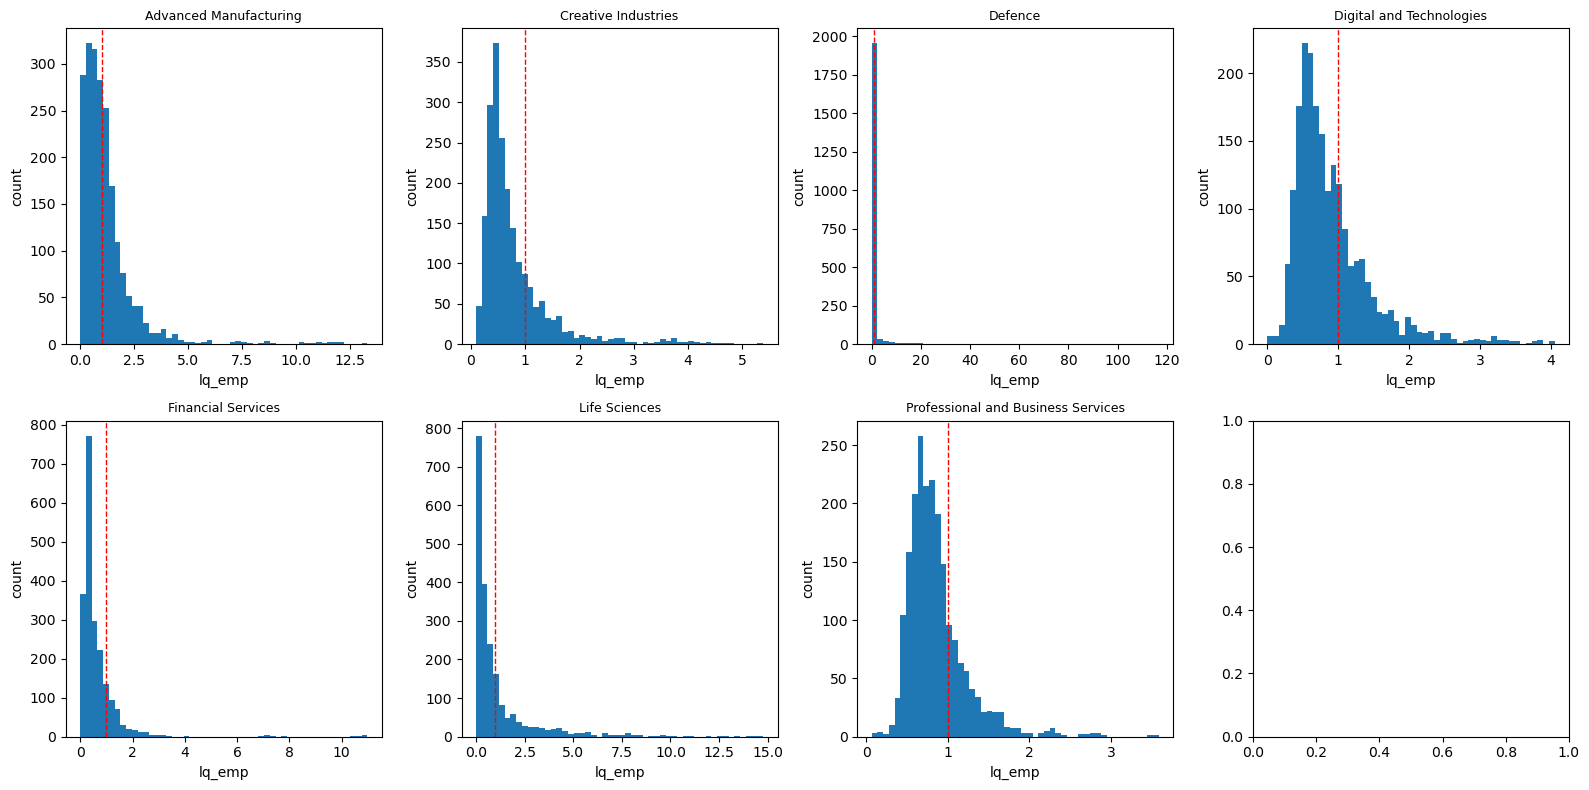

saved


In [ ]:
import matplotlib.pyplot as plt

sectors = panel["IS8_SECTOR"].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, sector in enumerate(sorted(sectors)):
    ax = axes[i]
    data = panel[panel["IS8_SECTOR"] == sector]["lq_emp"].dropna()
    ax.hist(data, bins=50, edgecolor="none")
    ax.axvline(1, color="red", linestyle="--", linewidth=1)
    ax.set_title(sector, fontsize=9)
    ax.set_xlabel("lq_emp")
    ax.set_ylabel("count")

plt.tight_layout()
plt.savefig("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/output/graphs/franco/stress_test_1_lq_distributions.png", dpi=150)
plt.show()
print("saved")

In [ ]:
# top 10 highest lq_emp values per sector, with LAD name and employee count
print("=== Top 10 extreme lq_emp values per sector ===\n")
for sector in sorted(panel["IS8_SECTOR"].unique()):
    top = (
        panel[panel["IS8_SECTOR"] == sector]
        .nlargest(10, "lq_emp")[["GEOGRAPHY_NAME", "YEAR", "lq_emp", "EMPLOYEES"]]
        .reset_index(drop=True)
    )
    print(f"--- {sector} ---")
    print(top.to_string())
    print()

=== Top 10 extreme lq_emp values per sector ===

--- Advanced Manufacturing ---
  GEOGRAPHY_NAME  YEAR     lq_emp  EMPLOYEES
0  Ribble Valley  2022  13.292785    10070.0
1          Fylde  2021  12.134333    12735.0
2  Ribble Valley  2021  11.998078     9200.0
3          Fylde  2020   11.89821    12760.0
4  Ribble Valley  2020  11.882903     9655.0
5          Fylde  2022  11.630502    12750.0
6          Fylde  2019   11.52902    12815.0
7  Ribble Valley  2017  11.417978     8855.0
8  Ribble Valley  2019  11.149668     9295.0
9          Fylde  2018  11.078711    12790.0

--- Creative Industries ---
           GEOGRAPHY_NAME  YEAR    lq_emp  EMPLOYEES
0                Hounslow  2022  5.382184    49055.0
1  Hammersmith and Fulham  2016  4.790984    34635.0
2  Hammersmith and Fulham  2017  4.696136    33305.0
3  Hammersmith and Fulham  2022  4.616229    38295.0
4  Hammersmith and Fulham  2021  4.513437    34525.0
5  Hammersmith and Fulham  2018   4.42655    31875.0
6  Hammersmith and Fulham

In [ ]:
# directional agreement between lq_emp and lq_bus
# both above or both below 1 = agreement
panel_sectors = panel[panel["IS8_SECTOR"] != "Defence"].copy()
panel_sectors["lq_emp_above"] = panel_sectors["lq_emp"] > 1
panel_sectors["lq_bus_above"] = panel_sectors["lq_bus"] > 1
panel_sectors["agree"] = panel_sectors["lq_emp_above"] == panel_sectors["lq_bus_above"]

print("=== LQ_emp vs LQ_bus directional agreement ===\n")
print(f"Overall agreement rate: {panel_sectors['agree'].mean()*100:.1f}%")
print()
print("Agreement rate by sector:")
print(panel_sectors.groupby("IS8_SECTOR")["agree"].mean().mul(100).round(1).to_string())
print()

# disagreement cases — where one is above 1 and the other below
disagree = panel_sectors[~panel_sectors["agree"]][["GEOGRAPHY_NAME", "IS8_SECTOR", "YEAR", "lq_emp", "lq_bus"]].dropna()
print(f"\nTotal disagreement cases: {len(disagree)}")
print("\nSample disagreements:")
print(disagree.sample(10, random_state=42).to_string())

=== LQ_emp vs LQ_bus directional agreement ===

Overall agreement rate: 79.9%

Agreement rate by sector:
IS8_SECTOR
Advanced Manufacturing                76.2
Creative Industries                   89.0
Digital and Technologies              80.7
Financial Services                    82.1
Life Sciences                         70.6
Professional and Business Services    80.5


Total disagreement cases: 2503

Sample disagreements:
       GEOGRAPHY_NAME                          IS8_SECTOR  YEAR    lq_emp    lq_bus
3353        Lichfield              Advanced Manufacturing  2017  1.434592  0.958558
6573          Bedford              Advanced Manufacturing  2019  0.673673  1.054325
9303     South Ribble              Advanced Manufacturing  2020  1.238169  0.890933
8238        Redbridge  Professional and Business Services  2019  0.977777  1.162506
10200       Greenwich                 Creative Industries  2020  0.955324   1.67285
4520   Northumberland                       Life Sciences  2018  3

In [ ]:
import pandas as pd
import numpy as np

panel = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

SY_LADS = ["Sheffield", "Doncaster", "Rotherham", "Barnsley"]
SECTORS = [s for s in panel["IS8_SECTOR"].unique() if s != "Defence"]
YEARS = list(range(2016, 2023))
EXPECTED_ROWS = 296 * 7 * 7  # LADs x sectors x years (inc. Defence)

issues = []

# ============================================================
# 1. STRUCTURAL INTEGRITY
# ============================================================
print("=" * 60)
print("1. STRUCTURAL INTEGRITY")
print("=" * 60)

# 1a. total row count
print(f"\n[1a] Total rows: {len(panel):,} (expected {EXPECTED_ROWS:,})")
if len(panel) != EXPECTED_ROWS:
    issues.append(f"[1a] Row count mismatch: {len(panel)} vs {EXPECTED_ROWS}")

# 1b. every LAD appears exactly 7 times per year (once per sector)
lad_year_counts = panel.groupby(["GEOGRAPHY_CODE", "YEAR"])["IS8_SECTOR"].count()
unexpected = lad_year_counts[lad_year_counts != 7]
print(f"\n[1b] LAD x year combinations with != 7 sectors: {len(unexpected)}")
if len(unexpected) > 0:
    issues.append(f"[1b] {len(unexpected)} LAD x year combinations have wrong sector count")
    print(unexpected.head(10))

# 1c. every year appears same number of times
year_counts = panel["YEAR"].value_counts().sort_index()
print(f"\n[1c] Row count per year:")
print(year_counts.to_string())
if year_counts.nunique() > 1:
    issues.append("[1c] Unequal row counts across years")

# 1d. duplicate LAD x sector x year
dupes = panel.duplicated(subset=["GEOGRAPHY_CODE", "IS8_SECTOR", "YEAR"]).sum()
print(f"\n[1d] Duplicate LAD x sector x year rows: {dupes}")
if dupes > 0:
    issues.append(f"[1d] {dupes} duplicate rows found")

# ============================================================
# 2. VALUE RANGE CHECKS
# ============================================================
print("\n" + "=" * 60)
print("2. VALUE RANGE CHECKS")
print("=" * 60)

# 2a. LQ >= 0
for col in ["lq_emp", "lq_bus"]:
    n_neg = (panel[col] < 0).sum()
    print(f"\n[2a] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2a] {n_neg} negative values in {col}")

# 2b. EMPLOYEES and BUSINESSES >= 0
for col in ["EMPLOYEES", "BUSINESSES"]:
    n_neg = (panel[col] < 0).sum()
    print(f"[2b] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2b] {n_neg} negative values in {col}")

# 2c. shares between 0 and 1
share_cols = ["emp_share", "size_large_share", "size_micro_share"]
for col in share_cols:
    n_out = ((panel[col] < 0) | (panel[col] > 1)).sum()
    print(f"[2c] {col} outside [0,1]: {n_out}")
    if n_out > 0:
        issues.append(f"[2c] {n_out} values outside [0,1] in {col}")

# 2d. diversity measures >= 0
for col in ["related_variety", "within_sector_diversity"]:
    n_neg = (panel[col] < 0).sum()
    print(f"[2d] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2d] {n_neg} negative values in {col}")

# ============================================================
# 3. JOIN INTEGRITY
# ============================================================
print("\n" + "=" * 60)
print("3. JOIN INTEGRITY")
print("=" * 60)

x_vars = [
    "nvq_level3", "gcse_age19", "apprenticeship_starts",
    "apprenticeship_achievements", "fe_participation",
    "enterprise_birth_rate", "enterprise_death_rate",
    "enterprise_high_growth_rate",
    "transport_to_employer", "drive_to_employer",
    "cycle_to_employer", "broadband", "coverage_4g",
    "unemployment_rate", "housing_net_additions"
]

# 3a. LADs with all X variables null (complete join failure)
lad_x = panel.drop_duplicates("GEOGRAPHY_CODE")[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"] + x_vars]
all_null = lad_x[lad_x[x_vars].isnull().all(axis=1)]
print(f"\n[3a] LADs with ALL X variables null: {len(all_null)}")
if len(all_null) > 0:
    issues.append(f"[3a] {len(all_null)} LADs have complete X variable join failure")
    print(all_null[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]])

# 3b. GD null where n_years >= 4 (should never happen)
gd_issue_emp = panel[(panel["n_years_emp"] >= 4) & panel["gd_emp"].isna()]
gd_issue_bus = panel[(panel["n_years_bus"] >= 4) & panel["gd_bus"].isna()]
print(f"\n[3b] gd_emp null where n_years_emp >= 4: {len(gd_issue_emp)}")
print(f"[3b] gd_bus null where n_years_bus >= 4: {len(gd_issue_bus)}")
if len(gd_issue_emp) > 0:
    issues.append(f"[3b] {len(gd_issue_emp)} rows have gd_emp null despite n_years_emp >= 4")
if len(gd_issue_bus) > 0:
    issues.append(f"[3b] {len(gd_issue_bus)} rows have gd_bus null despite n_years_bus >= 4")

# ============================================================
# 4. SOUTH YORKSHIRE COMPLETENESS
# ============================================================
print("\n" + "=" * 60)
print("4. SOUTH YORKSHIRE COMPLETENESS")
print("=" * 60)

sy = panel[panel["GEOGRAPHY_NAME"].isin(SY_LADS)]
print(f"\n[4a] SY LADs found: {sorted(sy['GEOGRAPHY_NAME'].unique())}")

# 4a. all 4 SY LADs present
missing_sy = [lad for lad in SY_LADS if lad not in sy["GEOGRAPHY_NAME"].values]
if missing_sy:
    issues.append(f"[4a] Missing SY LADs: {missing_sy}")

# 4b. all sectors and years present for each SY LAD
for lad in SY_LADS:
    lad_df = sy[sy["GEOGRAPHY_NAME"] == lad]
    missing_years = set(YEARS) - set(lad_df["YEAR"].unique())
    missing_sectors = set(panel["IS8_SECTOR"].unique()) - set(lad_df["IS8_SECTOR"].unique())
    print(f"\n[4b] {lad}: {len(lad_df)} rows | missing years: {missing_years} | missing sectors: {missing_sectors}")
    if missing_years or missing_sectors:
        issues.append(f"[4b] {lad} missing years={missing_years} sectors={missing_sectors}")

# 4c. Y variables fully populated for SY LADs
print(f"\n[4c] SY Y variable null counts:")
for col in ["lq_emp", "lq_bus", "gd_emp", "gd_bus"]:
    null_count = sy[col].isna().sum()
    print(f"  {col}: {null_count} nulls")
    if null_count > 0 and col in ["lq_emp", "lq_bus"]:
        issues.append(f"[4c] {col} has {null_count} nulls in SY LADs")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
if issues:
    print(f"\n{len(issues)} issue(s) found:")
    for issue in issues:
        print(f"  ❌ {issue}")
else:
    print("\n✅ No dataset consistency issues found")

1. STRUCTURAL INTEGRITY

[1a] Total rows: 14,504 (expected 14,504)

[1b] LAD x year combinations with != 7 sectors: 0

[1c] Row count per year:
YEAR
2016    2072
2017    2072
2018    2072
2019    2072
2020    2072
2021    2072
2022    2072

[1d] Duplicate LAD x sector x year rows: 0

2. VALUE RANGE CHECKS

[2a] lq_emp negative values: 0

[2a] lq_bus negative values: 0
[2b] EMPLOYEES negative values: 0
[2b] BUSINESSES negative values: 0
[2c] emp_share outside [0,1]: 0
[2c] size_large_share outside [0,1]: 0
[2c] size_micro_share outside [0,1]: 0
[2d] related_variety negative values: 0
[2d] within_sector_diversity negative values: 0

3. JOIN INTEGRITY

[3a] LADs with ALL X variables null: 0

[3b] gd_emp null where n_years_emp >= 4: 0
[3b] gd_bus null where n_years_bus >= 4: 0

4. SOUTH YORKSHIRE COMPLETENESS

[4a] SY LADs found: ['Barnsley', 'Doncaster', 'Rotherham', 'Sheffield']

[4b] Sheffield: 49 rows | missing years: set() | missing sectors: set()

[4b] Doncaster: 49 rows | missing ye

In [ ]:
expected = {
    # percentages (0-100)
    "nvq_level3":                    ("percentage",   0, 100),
    "gcse_age19":                    ("percentage",   0, 100),
    "broadband":                     ("percentage",   0, 100),
    "coverage_4g":                   ("percentage",   0, 100),
    "unemployment_rate":             ("percentage",   0, 100),
    # rates per 100,000 population
    "apprenticeship_starts":         ("rate per 100k", 0, 5000),
    "apprenticeship_achievements":   ("rate per 100k", 0, 5000),
    "fe_participation":              ("rate per 100k", 0, 20000),
    # enterprise rates (0-1)
    "enterprise_birth_rate":         ("rate",         0, 1),
    "enterprise_death_rate":         ("rate",         0, 1),
    "enterprise_high_growth_rate":   ("rate",         0, 1),
    # minutes
    "transport_to_employer":         ("minutes",      0, 120),
    "drive_to_employer":             ("minutes",      0, 60),
    "cycle_to_employer":             ("minutes",      0, 120),
    # net additions per 1,000 stock
    "housing_net_additions":         ("per 1k stock", -10, 50),
    # proportions (0-1)
    "emp_share":                     ("proportion",   0, 1),
    "size_large_share":              ("proportion",   0, 1),
    "size_micro_share":              ("proportion",   0, 1),
    # entropy (>=0)
    "related_variety":               ("entropy",      0, 5),
    "within_sector_diversity":       ("entropy",      0, 5),
}

lad_snap = panel.drop_duplicates("GEOGRAPHY_CODE")

print(f"{'Variable':<30} {'Scale':<18} {'Min':>8} {'Mean':>8} {'Max':>8}  {'Expected range'}")
print("-" * 90)
for col, (scale, lo, hi) in expected.items():
    if col in lad_snap.columns:
        mn = lad_snap[col].min()
        mu = lad_snap[col].mean()
        mx = lad_snap[col].max()
        flag = " ⚠️" if (mn < lo or mx > hi) else ""
        print(f"{col:<30} {scale:<18} {mn:>8.4f} {mu:>8.4f} {mx:>8.4f}  [{lo}, {hi}]{flag}")
    else:
        print(f"{col:<30} MISSING FROM PANEL")

Variable                       Scale                   Min     Mean      Max  Expected range
------------------------------------------------------------------------------------------
nvq_level3                     percentage          37.8000  60.4672  85.7000  [0, 100]
gcse_age19                     percentage          53.1532  75.1331  88.6408  [0, 100]
broadband                      percentage           1.7000  74.8106  98.6000  [0, 100]
coverage_4g                    percentage          85.8400  99.4973 100.0000  [0, 100]
unemployment_rate              percentage           1.7000   3.6288   7.3000  [0, 100]
apprenticeship_starts          rate per 100k      264.0000 954.4155 2736.0000  [0, 5000]
apprenticeship_achievements    rate per 100k      111.0000 461.7695 1493.0000  [0, 5000]
fe_participation               rate per 100k      2611.0000 5232.9865 11994.0000  [0, 20000]
enterprise_birth_rate          rate                 0.0606   0.1123   0.2045  [0, 1]
enterprise_death_rate    

In [ ]:
for sector in sorted(panel["IS8_SECTOR"].unique()):
    data = panel[panel["IS8_SECTOR"] == sector]["lq_bus"].dropna()
    print(f"{sector:<40} min={data.min():.2f}  mean={data.mean():.2f}  max={data.max():.2f}  p99={data.quantile(0.99):.2f}")

Advanced Manufacturing                   min=0.00  mean=1.01  max=4.86  p99=2.31
Creative Industries                      min=0.00  mean=0.85  max=3.31  p99=2.43
Defence                                  min=0.00  mean=0.05  max=12.79  p99=0.00
Digital and Technologies                 min=0.00  mean=0.93  max=2.40  p99=1.87
Financial Services                       min=0.00  mean=0.85  max=7.83  p99=3.26
Life Sciences                            min=0.00  mean=0.72  max=9.73  p99=5.15
Professional and Business Services       min=0.13  mean=0.92  max=2.45  p99=1.73


In [ ]:
for sector in sorted(panel["IS8_SECTOR"].unique()):
    for col in ["gd_emp", "gd_bus"]:
        data = panel[panel["IS8_SECTOR"] == sector][col].dropna()
        if len(data) == 0:
            continue
        print(f"{sector:<40} {col}  min={data.min():.4f}  mean={data.mean():.4f}  max={data.max():.4f}  p1={data.quantile(0.01):.4f}  p99={data.quantile(0.99):.4f}")
    print()

Advanced Manufacturing                   gd_emp  min=-0.2493  mean=-0.0016  max=0.2595  p1=-0.1506  p99=0.1427
Advanced Manufacturing                   gd_bus  min=-0.1000  mean=-0.0019  max=0.1826  p1=-0.0895  p99=0.1102

Creative Industries                      gd_emp  min=-0.1313  mean=-0.0068  max=0.0969  p1=-0.1024  p99=0.0847
Creative Industries                      gd_bus  min=-0.0363  mean=-0.0013  max=0.0971  p1=-0.0336  p99=0.0498

Defence                                  gd_emp  min=-0.1792  mean=0.0089  max=0.2814  p1=-0.1792  p99=0.2814
Defence                                  gd_bus  min=-0.0066  mean=-0.0066  max=-0.0066  p1=-0.0066  p99=-0.0066

Digital and Technologies                 gd_emp  min=-0.1225  mean=-0.0120  max=0.1025  p1=-0.0888  p99=0.0721
Digital and Technologies                 gd_bus  min=-0.0734  mean=-0.0037  max=0.0786  p1=-0.0513  p99=0.0562

Financial Services                       gd_emp  min=-0.2197  mean=-0.0159  max=0.1807  p1=-0.1673  p99=0.1

In [ ]:
flags = [
    ("lq_emp",  "Life Sciences",             "right"),
    ("lq_emp",  "Advanced Manufacturing",    "right"),
    ("lq_emp",  "Financial Services",        "right"),
    ("lq_bus",  "Life Sciences",             "right"),
    ("lq_bus",  "Financial Services",        "right"),
    ("gd_emp",  "Life Sciences",             "both"),
    ("gd_bus",  "Life Sciences",             "both"),
]

print(f"{'Variable':<10} {'Sector':<40} {'Tail':<8} {'N total':>8} {'N winsorised':>13} {'% winsorised':>13}")
print("-" * 100)

for col, sector, tail in flags:
    data = panel[panel["IS8_SECTOR"] == sector][col].dropna()
    n_total = len(data)
    
    if tail == "right":
        threshold = data.quantile(0.99)
        n_wins = (data > threshold).sum()
    elif tail == "both":
        lo = data.quantile(0.01)
        hi = data.quantile(0.99)
        n_wins = ((data < lo) | (data > hi)).sum()
    
    pct = n_wins / n_total * 100
    print(f"{col:<10} {sector:<40} {tail:<8} {n_total:>8} {n_wins:>13} {pct:>12.1f}%")

Variable   Sector                                   Tail      N total  N winsorised  % winsorised
----------------------------------------------------------------------------------------------------
lq_emp     Life Sciences                            right        2072            21          1.0%
lq_emp     Advanced Manufacturing                   right        2072            21          1.0%
lq_emp     Financial Services                       right        2072            21          1.0%
lq_bus     Life Sciences                            right        2072            21          1.0%
lq_bus     Financial Services                       right        2072            21          1.0%
gd_emp     Life Sciences                            both         1911            28          1.5%
gd_bus     Life Sciences                            both         1617            28          1.7%


In [ ]:
ca_lookup = pd.read_csv("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/MSOA_to_English_combined_authorities.csv")
print(ca_lookup["CAUTH23NM"].unique())

<ArrowStringArray>
[                    'Tees Valley',           'Liverpool City Region',
                 'West of England', 'Cambridgeshire and Peterborough',
                      'North East',                   'North of Tyne',
              'Greater Manchester',                 'South Yorkshire',
                   'West Midlands',                  'West Yorkshire']
Length: 10, dtype: str


In [ ]:
print(ca_lookup[ca_lookup["CAUTH23NM"].str.contains("Midland", case=False, na=False)])
print(ca_lookup[ca_lookup["LAD23NM"].str.contains("Derby|Nottingham|Leicester", case=False, na=False)][["CAUTH23NM", "LAD23CD", "LAD23NM"]].drop_duplicates())

       MSOA21CD           MSOA21NM    LAD23CD        LAD23NM  CAUTH23CD  \
1144  E02001827     Birmingham 001  E08000025     Birmingham  E47000007   
1145  E02001828     Birmingham 002  E08000025     Birmingham  E47000007   
1146  E02001829     Birmingham 003  E08000025     Birmingham  E47000007   
1147  E02001830     Birmingham 004  E08000025     Birmingham  E47000007   
1148  E02001831     Birmingham 005  E08000025     Birmingham  E47000007   
...         ...                ...        ...            ...        ...   
1658  E02002179  Wolverhampton 031  E08000031  Wolverhampton  E47000007   
1659  E02002180  Wolverhampton 032  E08000031  Wolverhampton  E47000007   
1660  E02002181  Wolverhampton 033  E08000031  Wolverhampton  E47000007   
1661  E02002182  Wolverhampton 034  E08000031  Wolverhampton  E47000007   
1662  E02006894  Wolverhampton 035  E08000031  Wolverhampton  E47000007   

          CAUTH23NM  
1144  West Midlands  
1145  West Midlands  
1146  West Midlands  
1147  West 

In [ ]:
em_lads = [
    "Derby", "Derbyshire", "Nottingham", "Nottinghamshire",
    "Leicester", "Leicestershire"
]

matches = (
    panel[panel["GEOGRAPHY_NAME"].isin(em_lads)]
    [["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]]
    .drop_duplicates()
    .sort_values("GEOGRAPHY_NAME")
)
print(matches.to_string())
print(f"\nMatched {len(matches)} of {len(em_lads)} LADs")

    GEOGRAPHY_CODE GEOGRAPHY_NAME
98       E06000015          Derby
105      E06000016      Leicester
119      E06000018     Nottingham

Matched 3 of 6 LADs


In [ ]:
em_districts = panel[
    panel["GEOGRAPHY_NAME"].str.contains(
        "Derbyshire|Nottinghamshire|Leicestershire|Rutland|Amber|Bolsover|Chesterfield|"
        "Erewash|High Peak|North East Derbyshire|South Derbyshire|Ashfield|Basford|"
        "Broxtowe|Gedling|Mansfield|Newark|Rushcliffe|Blaby|Charnwood|Harborough|"
        "Hinckley|Melton|North West Leicestershire|Oadby",
        case=False, na=False
    )
][["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]].drop_duplicates().sort_values("GEOGRAPHY_NAME")

print(matches.to_string())
print(f"\nTotal: {len(em_districts)} LADs")

    GEOGRAPHY_CODE GEOGRAPHY_NAME
98       E06000015          Derby
105      E06000016      Leicester
119      E06000018     Nottingham

Total: 22 LADs


In [ ]:
print(em_districts.to_string())
print(f"\nTotal: {len(em_districts)} LADs")

     GEOGRAPHY_CODE             GEOGRAPHY_NAME
476       E07000032               Amber Valley
1183      E07000170                   Ashfield
1036      E07000129                      Blaby
483       E07000033                   Bolsover
1197      E07000172                   Broxtowe
1043      E07000130                  Charnwood
490       E07000034               Chesterfield
497       E07000035           Derbyshire Dales
504       E07000036                    Erewash
1204      E07000173                    Gedling
1050      E07000131                 Harborough
511       E07000037                  High Peak
1057      E07000132      Hinckley and Bosworth
1211      E07000174                  Mansfield
1064      E07000133                     Melton
1218      E07000175        Newark and Sherwood
518       E07000038      North East Derbyshire
1071      E07000134  North West Leicestershire
1078      E07000135          Oadby and Wigston
1225      E07000176                 Rushcliffe
112       E06

In [ ]:
# Flag 4 — North East
print("=== North East ===")
print(ca_lookup[ca_lookup["CAUTH23NM"] == "North East"][["LAD23CD", "LAD23NM"]].drop_duplicates().to_string())
print()
print("=== North of Tyne ===")
print(ca_lookup[ca_lookup["CAUTH23NM"] == "North of Tyne"][["LAD23CD", "LAD23NM"]].drop_duplicates().to_string())

# Flag 5 — Cambridge
print("\n=== Cambridgeshire and Peterborough ===")
print(ca_lookup[ca_lookup["CAUTH23NM"] == "Cambridgeshire and Peterborough"][["LAD23CD", "LAD23NM"]].drop_duplicates().to_string())
print()
print("=== config candidate_regions ===")
print(config["parameters"]["candidate_regions"])

# Full picture — all CAs and their LAD counts
print("\n=== All CAs in lookup ===")
print(ca_lookup.groupby("CAUTH23NM")["LAD23NM"].nunique().sort_values(ascending=False).to_string())

=== North East ===
        LAD23CD         LAD23NM
245   E06000047   County Durham
937   E08000024      Sunderland
1063  E08000023  South Tyneside
1764  E08000037       Gateshead

=== North of Tyne ===
       LAD23CD              LAD23NM
310  E06000057       Northumberland
940  E08000022       North Tyneside
941  E08000021  Newcastle upon Tyne

=== Cambridgeshire and Peterborough ===
       LAD23CD               LAD23NM
108  E06000031          Peterborough
348  E07000008             Cambridge
350  E07000011       Huntingdonshire
355  E07000012  South Cambridgeshire
386  E07000009   East Cambridgeshire
396  E07000010               Fenland

=== config candidate_regions ===
['South Yorkshire MCA', 'West Midlands CA', 'West Yorkshire CA', 'Greater Manchester CA', 'West of England CA', 'Glasgow City Region', 'Cardiff-Newport']

=== All CAs in lookup ===
CAUTH23NM
Greater Manchester                 10
West Midlands                       7
Cambridgeshire and Peterborough     6
Liverpool City 

In [ ]:
ca_lookup = pd.read_csv("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/MSOA_to_English_combined_authorities.csv")

# LADs in any CA
ca_lads = ca_lookup[["LAD23CD", "LAD23NM", "CAUTH23NM"]].drop_duplicates()
print(f"LADs in a CA: {ca_lads['LAD23CD'].nunique()}")

# LADs in panel but not in any CA
panel_lads = panel[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]].drop_duplicates()
not_in_ca = panel_lads[~panel_lads["GEOGRAPHY_CODE"].isin(ca_lads["LAD23CD"])]
print(f"LADs not in any CA: {len(not_in_ca)}")
print(f"Total panel LADs: {panel_lads['GEOGRAPHY_CODE'].nunique()}")

LADs in a CA: 53
LADs not in any CA: 243
Total panel LADs: 296


In [ ]:
import os

# search for any region-related files in the boundaries folder
boundaries_path = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries"
for f in os.listdir(boundaries_path):
    print(f)

MSOA_to_English_combined_authorities.csv
Middle_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V3_-4477917303172606123.geojson
IZ2022_to_council_area.csv
MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V2).csv
SG_IZ_2022.geojson
UK_Local_Authority_Districts_December_2023_Boundaries_UK_BGC_2537431731774104276.geojson


In [ ]:
ca_lookup = pd.read_csv("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/MSOA_to_English_combined_authorities.csv")
print(ca_lookup.columns.tolist())
print(ca_lookup.shape)

['MSOA21CD', 'MSOA21NM', 'LAD23CD', 'LAD23NM', 'CAUTH23CD', 'CAUTH23NM']
(1941, 6)


In [ ]:
msoa_lookup = pd.read_csv("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/boundaries/MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V2).csv")
print(msoa_lookup.columns.tolist())

['MSOA11CD', 'MSOA11NM', 'CHGIND', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LAD22NMW', 'ObjectId']


In [ ]:
emp = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/employee_counts/Employee_counts_IS8_LADs.parquet")
print(emp["GEOGRAPHY_TYPE"].unique())

<ArrowStringArray>
['local authorities: district / unitary (as of April 2023)', 'countries']
Length: 2, dtype: str


In [ ]:
bus = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/business_counts/Business_counts_IS8_LADs.parquet")
print(bus["GEOGRAPHY_TYPE"].unique())

<ArrowStringArray>
['local authorities: district / unitary (as of April 2023)', 'countries']
Length: 2, dtype: str


In [ ]:
panel[panel["GEOGRAPHY_NAME"].str.contains("Darlington", case=False, na=False)][["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]].drop_duplicates().sort_values("GEOGRAPHY_NAME")

,GEOGRAPHY_CODE,GEOGRAPHY_NAME
28,E06000005,Darlington


In [ ]:
The previous cell didn't run successfully — `lad_region` was never created. Run the full extraction again:

```python
import pandas as pd

ons_file = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/local_indicators/ONS_local_indicators_package.xlsx"

df = pd.read_excel(ons_file, sheet_name="Weekly pay", header=None)

# find header row
for i, row in df.iterrows():
    if any("Area Code" in str(v) for v in row.values):
        header_row = i
        break

df.columns = df.iloc[header_row]
df = df.iloc[header_row + 1:].reset_index(drop=True)
df = df.rename(columns={df.columns[0]: "GEOGRAPHY_CODE"})

# forward fill region
df["Region"] = df["Region"].ffill()

# keep only rows matching panel LAD codes
df["GEOGRAPHY_CODE"] = df["GEOGRAPHY_CODE"].astype(str)
panel["GEOGRAPHY_CODE"] = panel["GEOGRAPHY_CODE"].astype(str)

lad_region = df[df["GEOGRAPHY_CODE"].isin(panel["GEOGRAPHY_CODE"])][["GEOGRAPHY_CODE", "Region"]].drop_duplicates()

print(f"LADs mapped: {len(lad_region)}")
print(f"LADs unmatched: {panel['GEOGRAPHY_CODE'].nunique() - len(lad_region)}")
print("\nRegion counts:")
print(lad_region["Region"].value_counts())

# unmatched
matched_codes = lad_region["GEOGRAPHY_CODE"].tolist()
unmatched = panel[~panel["GEOGRAPHY_CODE"].isin(matched_codes)][["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"]].drop_duplicates()
print(f"\nUnmatched LADs ({len(unmatched)}):")
print(unmatched.to_string())
```

SyntaxError: unterminated string literal (detected at line 1) (2768077797.py, line 1)

In [ ]:
import pandas as pd

ons_file = "/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/local_indicators/ONS_local_indicators_package.xlsx"

df = pd.read_excel(ons_file, sheet_name="Weekly pay", header=None)

# find header row
for i, row in df.iterrows():
    if any("Area Code" in str(v) for v in row.values):
        header_row = i
        break

df.columns = df.iloc[header_row]
df = df.iloc[header_row + 1:].reset_index(drop=True)
df = df.rename(columns={df.columns[0]: "GEOGRAPHY_CODE"})

# forward fill region and county/UA
df["Region"] = df["Region"].ffill()
df["County or Unitary Authority"] = df["County or Unitary Authority"].ffill()

print(df.columns.tolist())
print(df[["GEOGRAPHY_CODE", "Region", "County or Unitary Authority", "Local Authority District"]].head(30).to_string())

['GEOGRAPHY_CODE', 'Country', 'Nation', 'Region', 'County or Unitary Authority', 'Local Authority District', 'Gross median weekly pay (£)', 'Lower 95% Confidence Interval', 'Upper 95% Confidence Interval', 'Notes']
10 GEOGRAPHY_CODE       Region      County or Unitary Authority Local Authority District
0       K02000001          NaN                              NaN                      NaN
1       K03000001          NaN                              NaN                      NaN
2       K04000001          NaN                              NaN                      NaN
3       E92000001          NaN                              NaN                      NaN
4       E12000001   North East                              NaN                      NaN
5       E06000047   North East                    County Durham                      NaN
6       E06000005   North East                       Darlington                      NaN
7       E06000001   North East                       Hartlepool          

In [ ]:
# filter to LAD-level rows only
lad_rows = df[df["GEOGRAPHY_CODE"].str.match(r"^E0[6-9]\d{6}$", na=False)].copy()

# for unitary authorities, LAD name is in County/UA column
# for districts, LAD name is in Local Authority District column
lad_rows["LAD_NAME"] = lad_rows["Local Authority District"].fillna(
    lad_rows["County or Unitary Authority"]
)

lad_hierarchy = lad_rows[["GEOGRAPHY_CODE", "Region", "County or Unitary Authority", "LAD_NAME"]].copy()

print(f"Total LAD rows extracted: {len(lad_hierarchy)}")
print(f"\nSample:")
print(lad_hierarchy.head(20).to_string())

# check against panel
matched = lad_hierarchy[lad_hierarchy["GEOGRAPHY_CODE"].isin(panel["GEOGRAPHY_CODE"])]
print(f"\nMatched to panel: {len(matched)} of {panel['GEOGRAPHY_CODE'].nunique()} LADs")

Total LAD rows extracted: 296

Sample:
10 GEOGRAPHY_CODE       Region County or Unitary Authority                   LAD_NAME
5       E06000047   North East               County Durham              County Durham
6       E06000005   North East                  Darlington                 Darlington
7       E06000001   North East                  Hartlepool                 Hartlepool
8       E06000002   North East               Middlesbrough              Middlesbrough
9       E06000057   North East              Northumberland             Northumberland
10      E06000003   North East        Redcar and Cleveland       Redcar and Cleveland
11      E06000004   North East            Stockton-on-Tees           Stockton-on-Tees
13      E08000037   North East  Tyne and Wear (Met County)                  Gateshead
14      E08000021   North East  Tyne and Wear (Met County)        Newcastle upon Tyne
15      E08000022   North East  Tyne and Wear (Met County)             North Tyneside
16      E080000

In [10]:
print(panel[["GEOGRAPHY_NAME", "REGION", "COUNTY_UA"]].drop_duplicates().head(20).to_string())

                  GEOGRAPHY_NAME                    REGION                    COUNTY_UA
0                     Hartlepool                North East                   Hartlepool
7                  Middlesbrough                North East                Middlesbrough
14          Redcar and Cleveland                North East         Redcar and Cleveland
21              Stockton-on-Tees                North East             Stockton-on-Tees
28                    Darlington                North East                   Darlington
35                        Halton               North West                        Halton
42                    Warrington               North West                    Warrington
49         Blackburn with Darwen               North West         Blackburn with Darwen
56                     Blackpool               North West                     Blackpool
63   Kingston upon Hull, City of  Yorkshire and The Humber  Kingston upon Hull, City of
70      East Riding of Yorkshire

In [11]:
print(f"Shape: {panel.shape}")
print(f"Columns: {panel.columns.tolist()}")
print(f"REGION nulls: {panel['REGION'].isna().sum()}")
print(f"COUNTY_UA nulls: {panel['COUNTY_UA'].isna().sum()}")
print(f"\nREGION value counts:")
print(panel.drop_duplicates('GEOGRAPHY_CODE')['REGION'].value_counts())

Shape: (14504, 34)
Columns: ['YEAR', 'GEOGRAPHY_CODE', 'GEOGRAPHY_NAME', 'IS8_SECTOR', 'EMPLOYEES', 'BUSINESSES', 'unemployment_rate', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'broadband', 'coverage_4g', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'nvq_level3', 'fe_participation', 'housing_net_additions', 'enterprise_birth_rate', 'enterprise_death_rate', 'enterprise_high_growth_rate', 'REGION', 'COUNTY_UA', 'lq_bus', 'emp_share', 'lq_emp', 'gd_emp', 'gd_bus', 'n_years_emp', 'n_years_bus', 'related_variety', 'within_sector_diversity', 'size_large_share', 'size_micro_share']
REGION nulls: 0
COUNTY_UA nulls: 0

REGION value counts:
REGION
South East                  64
East of England             45
North West                  35
East Midlands               35
London                      33
West Midlands               30
South West                  27
Yorkshire and The Humber    15
North East                  12
Name: count, dtype: int64

In [12]:
emp = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/employee_counts/Employee_counts_IS8_LADs.parquet")
print(emp["YEAR"].unique())

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [13]:
bus = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/raw_data/business_counts/Business_counts_IS8_LADs.parquet")
print(bus["YEAR"].unique())

[2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [17]:
import pandas as pd
import numpy as np

panel = pd.read_parquet("/Users/francosebastiani/Documents/GitHub/Economic_Observatory/data/processed_data/analysis_panel.parquet")

SY_LADS = ["Sheffield", "Doncaster", "Rotherham", "Barnsley"]
SECTORS = [s for s in panel["IS8_SECTOR"].unique() if s != "Defence"]
YEARS = list(range(2016, 2024))
EXPECTED_ROWS = 296 * 7 * 8  # LADs x sectors x years

issues = []

# ============================================================
# 1. STRUCTURAL INTEGRITY
# ============================================================
print("=" * 60)
print("1. STRUCTURAL INTEGRITY")
print("=" * 60)

print(f"\n[1a] Total rows: {len(panel):,} (expected {EXPECTED_ROWS:,})")
if len(panel) != EXPECTED_ROWS:
    issues.append(f"[1a] Row count mismatch: {len(panel)} vs {EXPECTED_ROWS}")

lad_year_counts = panel.groupby(["GEOGRAPHY_CODE", "YEAR"])["IS8_SECTOR"].count()
unexpected = lad_year_counts[lad_year_counts != 7]
print(f"\n[1b] LAD x year combinations with != 7 sectors: {len(unexpected)}")
if len(unexpected) > 0:
    issues.append(f"[1b] {len(unexpected)} LAD x year combinations have wrong sector count")

year_counts = panel["YEAR"].value_counts().sort_index()
print(f"\n[1c] Row count per year:")
print(year_counts.to_string())
if year_counts.nunique() > 1:
    issues.append("[1c] Unequal row counts across years")

dupes = panel.duplicated(subset=["GEOGRAPHY_CODE", "IS8_SECTOR", "YEAR"]).sum()
print(f"\n[1d] Duplicate LAD x sector x year rows: {dupes}")
if dupes > 0:
    issues.append(f"[1d] {dupes} duplicate rows found")

# ============================================================
# 2. VALUE RANGE CHECKS
# ============================================================
print("\n" + "=" * 60)
print("2. VALUE RANGE CHECKS")
print("=" * 60)

for col in ["lq_emp", "lq_bus"]:
    n_neg = (panel[col] < 0).sum()
    print(f"\n[2a] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2a] {n_neg} negative values in {col}")

for col in ["EMPLOYEES", "BUSINESSES"]:
    n_neg = (panel[col] < 0).sum()
    print(f"[2b] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2b] {n_neg} negative values in {col}")

for col in ["emp_share", "size_large_share", "size_micro_share"]:
    n_out = ((panel[col] < 0) | (panel[col] > 1)).sum()
    print(f"[2c] {col} outside [0,1]: {n_out}")
    if n_out > 0:
        issues.append(f"[2c] {n_out} values outside [0,1] in {col}")

for col in ["related_variety", "within_sector_diversity"]:
    n_neg = (panel[col] < 0).sum()
    print(f"[2d] {col} negative values: {n_neg}")
    if n_neg > 0:
        issues.append(f"[2d] {n_neg} negative values in {col}")

# ============================================================
# 3. JOIN INTEGRITY
# ============================================================
print("\n" + "=" * 60)
print("3. JOIN INTEGRITY")
print("=" * 60)

x_vars = [
    "nvq_level3", "gcse_age19", "apprenticeship_starts",
    "apprenticeship_achievements", "fe_participation",
    "enterprise_birth_rate", "enterprise_death_rate",
    "enterprise_high_growth_rate", "transport_to_employer",
    "drive_to_employer", "cycle_to_employer", "broadband",
    "coverage_4g", "unemployment_rate", "housing_net_additions"
]

lad_x = panel.drop_duplicates("GEOGRAPHY_CODE")[["GEOGRAPHY_CODE", "GEOGRAPHY_NAME"] + x_vars]
all_null = lad_x[lad_x[x_vars].isnull().all(axis=1)]
print(f"\n[3a] LADs with ALL X variables null: {len(all_null)}")
if len(all_null) > 0:
    issues.append(f"[3a] {len(all_null)} LADs have complete X variable join failure")

gd_issue_emp = panel[(panel["n_years_emp"] >= 4) & panel["gd_emp"].isna()]
gd_issue_bus = panel[(panel["n_years_bus"] >= 4) & panel["gd_bus"].isna()]
print(f"\n[3b] gd_emp null where n_years_emp >= 4: {len(gd_issue_emp)}")
print(f"[3b] gd_bus null where n_years_bus >= 4: {len(gd_issue_bus)}")
if len(gd_issue_emp) > 0:
    issues.append(f"[3b] {len(gd_issue_emp)} rows have gd_emp null despite n_years_emp >= 4")
if len(gd_issue_bus) > 0:
    issues.append(f"[3b] {len(gd_issue_bus)} rows have gd_bus null despite n_years_bus >= 4")

# ============================================================
# 4. REGION AND COUNTY_UA INTEGRITY
# ============================================================
print("\n" + "=" * 60)
print("4. REGION AND COUNTY_UA INTEGRITY")
print("=" * 60)

print(f"\n[4a] REGION nulls: {panel['REGION'].isna().sum()}")
print(f"[4a] COUNTY_UA nulls: {panel['COUNTY_UA'].isna().sum()}")
if panel['REGION'].isna().sum() > 0:
    issues.append("[4a] REGION has unexpected nulls")
if panel['COUNTY_UA'].isna().sum() > 0:
    issues.append("[4a] COUNTY_UA has unexpected nulls")

print(f"\n[4b] Regions found: {sorted(panel['REGION'].dropna().unique().tolist())}")

# ============================================================
# 5. SOUTH YORKSHIRE COMPLETENESS
# ============================================================
print("\n" + "=" * 60)
print("5. SOUTH YORKSHIRE COMPLETENESS")
print("=" * 60)

sy = panel[panel["GEOGRAPHY_NAME"].isin(SY_LADS)]
print(f"\n[5a] SY LADs found: {sorted(sy['GEOGRAPHY_NAME'].unique())}")

for lad in SY_LADS:
    lad_df = sy[sy["GEOGRAPHY_NAME"] == lad]
    missing_years = set(YEARS) - set(lad_df["YEAR"].unique())
    missing_sectors = set(panel["IS8_SECTOR"].unique()) - set(lad_df["IS8_SECTOR"].unique())
    print(f"\n[5b] {lad}: {len(lad_df)} rows | missing years: {missing_years} | missing sectors: {missing_sectors}")

print(f"\n[5c] SY Y variable null counts:")
for col in ["lq_emp", "lq_bus", "gd_emp", "gd_bus"]:
    print(f"  {col}: {sy[col].isna().sum()} nulls")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
if issues:
    print(f"\n{len(issues)} issue(s) found:")
    for issue in issues:
        print(f"  ❌ {issue}")
else:
    print("\n✅ No dataset consistency issues found")

1. STRUCTURAL INTEGRITY

[1a] Total rows: 16,576 (expected 16,576)

[1b] LAD x year combinations with != 7 sectors: 0

[1c] Row count per year:
YEAR
2016    2072
2017    2072
2018    2072
2019    2072
2020    2072
2021    2072
2022    2072
2023    2072

[1d] Duplicate LAD x sector x year rows: 0

2. VALUE RANGE CHECKS

[2a] lq_emp negative values: 0

[2a] lq_bus negative values: 0
[2b] EMPLOYEES negative values: 0
[2b] BUSINESSES negative values: 0
[2c] emp_share outside [0,1]: 0
[2c] size_large_share outside [0,1]: 0
[2c] size_micro_share outside [0,1]: 0
[2d] related_variety negative values: 0
[2d] within_sector_diversity negative values: 0

3. JOIN INTEGRITY

[3a] LADs with ALL X variables null: 0

[3b] gd_emp null where n_years_emp >= 4: 0
[3b] gd_bus null where n_years_bus >= 4: 0

4. REGION AND COUNTY_UA INTEGRITY

[4a] REGION nulls: 0
[4a] COUNTY_UA nulls: 0

[4b] Regions found: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West'